# Handcrafted two-arm URDF render debug

基于已有 [`result.json`](ca-pi-xie-device-tools/reconstruct_two_arm.ipynb:56) / [`rise2_calib_20260104.npy`](build_rise2_calib_from_json.py:1) / converted [`lowdim/*.npy`](dataset/data_utils.py:18) 手搓一套双臂渲染与内联可视化。

In [ ]:
import os
import sys
import json
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from omegaconf import OmegaConf

WORKSPACE_ROOT = '/home/haoxiang/rise2_mask_aware'
AIREXO_ROOT = os.path.join(WORKSPACE_ROOT, 'airexo')
for p in [WORKSPACE_ROOT, AIREXO_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

for _m in [m for m in list(sys.modules.keys()) if m == 'airexo' or m.startswith('airexo.')]:
    del sys.modules[_m]

from airexo.calibration.calib_info import CalibrationInfo
from airexo.helpers.constants import (
    ROBOT_PREDEFINED_TRANSFORMATION,
    ROBOT_LEFT_REAL_BASE_TO_REAL_BASE,
    ROBOT_RIGHT_REAL_BASE_TO_REAL_BASE,
)
from airexo.helpers.rotation import average_xyz_rot_quat
from mask.renderer import ArmOnlyRobotRenderer

TASK_ROOT = Path('/data/haoxiang/data/task0012_260321/task0012_toys_basket_converted')
CALIB_DIR = Path('/data/haoxiang/data/task0012_260321/calib')
FAKE_CALIB_TIMESTAMP = '20260104_fake_airexo_robot'
LEFT_JSON = Path('/data/haoxiang/data/task0012_260321/calib/left_global_20260104/result.json')
RIGHT_JSON = Path('/data/haoxiang/data/task0012_260321/calib/right_global_20260104/result.json')
SCENE_NAME = 'scene_0001'
FRAME_STEM = '1774059832169'

def pose7_wxyz_to_mat(pose7):
    pose7 = np.asarray(pose7, dtype=np.float64).reshape(7)
    t = pose7[:3]
    qw, qx, qy, qz = pose7[3:]
    T = np.eye(4, dtype=np.float64)
    T[:3, :3] = R.from_quat([qx, qy, qz, qw]).as_matrix()
    T[:3, 3] = t
    return T

def load_pose_in_link(json_path):
    data = json.loads(Path(json_path).read_text())
    return pose7_wxyz_to_mat(np.asarray(data['pose_in_link'], dtype=np.float64))

def make_T_xyz_rpy(xyz, rpy):
    T = np.eye(4, dtype=np.float64)
    T[:3, :3] = R.from_euler('xyz', rpy).as_matrix()
    T[:3, 3] = np.asarray(xyz, dtype=np.float64)
    return T

# 直接从 robot.urdf 抄固定安装关系：left/right_base_link 相对于总 base
BASE_TO_LEFT_FROM_URDF = make_T_xyz_rpy([0.0, 0.135, 0.0], [-0.7853981633974483, 0.0, 0.0])
BASE_TO_RIGHT_FROM_URDF = make_T_xyz_rpy([0.0, -0.135, 0.0], [0.7853981633974483, 0.0, 0.0])
LEFT_TO_BASE_FROM_URDF = np.linalg.inv(BASE_TO_LEFT_FROM_URDF)
RIGHT_TO_BASE_FROM_URDF = np.linalg.inv(BASE_TO_RIGHT_FROM_URDF)

scene_path = TASK_ROOT / 'train' / SCENE_NAME
fake_calib = CalibrationInfo(calib_path=str(CALIB_DIR), calib_timestamp=FAKE_CALIB_TIMESTAMP)
camera_serial = list(fake_calib.camera_serials_global)[0]
intrinsic = fake_calib.get_intrinsic(camera_serial)
cam_path = scene_path / f'cam_{camera_serial}'
lowdim_path = scene_path / 'lowdim' / f'{FRAME_STEM}.npy'
rgb_path = cam_path / 'color' / f'{FRAME_STEM}.png'
depth_path = cam_path / 'depth' / f'{FRAME_STEM}.png'
assert lowdim_path.exists(), lowdim_path
assert rgb_path.exists(), rgb_path
assert depth_path.exists(), depth_path

cam_to_left_base = load_pose_in_link(LEFT_JSON)
cam_to_right_base = load_pose_in_link(RIGHT_JSON)

# 方案A：直接按 robot.urdf 的 base2left/base2right 提升到总 base
cam_to_base_left_urdf = cam_to_left_base @ LEFT_TO_BASE_FROM_URDF
cam_to_base_right_urdf = cam_to_right_base @ RIGHT_TO_BASE_FROM_URDF
cam_to_base_avg_urdf = average_xyz_rot_quat(cam_to_base_left_urdf, cam_to_base_right_urdf, rotation_rep='matrix')

# 方案B：严格按 CalibrationInfo 剩余链条思路补齐：
# camera->left/right_real_base -> overall_real_base -> renderer base
cam_to_overall_real_base_from_left = cam_to_left_base @ ROBOT_LEFT_REAL_BASE_TO_REAL_BASE
cam_to_overall_real_base_from_right = cam_to_right_base @ ROBOT_RIGHT_REAL_BASE_TO_REAL_BASE
cam_to_overall_real_base_avg = average_xyz_rot_quat(
    cam_to_overall_real_base_from_left,
    cam_to_overall_real_base_from_right,
    rotation_rep='matrix'
)
cam_to_base_official_chain = cam_to_overall_real_base_avg @ np.linalg.inv(ROBOT_PREDEFINED_TRANSFORMATION)

candidate_cam_to_base = {
    'left_to_base_urdf': cam_to_base_left_urdf,
    'right_to_base_urdf': cam_to_base_right_urdf,
    'avg_left_right_urdf': cam_to_base_avg_urdf,
    'official_remaining_chain': cam_to_base_official_chain,
    'fake_calib_get_camera_to_base': fake_calib.get_camera_to_base(camera_serial),
}

print('camera_serial =', camera_serial)
print('fake calib file =', CALIB_DIR / f'{FAKE_CALIB_TIMESTAMP}.npy')
print('cam_to_left_base =\n', cam_to_left_base)
print('cam_to_right_base =\n', cam_to_right_base)
print('\ncam_to_overall_real_base_from_left =\n', cam_to_overall_real_base_from_left)
print('\ncam_to_overall_real_base_from_right =\n', cam_to_overall_real_base_from_right)
print('\ncam_to_base_official_chain =\n', cam_to_base_official_chain)
for name, T in candidate_cam_to_base.items():
    print(f'\n[{name}]')
    print(T)

# 继续排查：在官方剩余链条基础上，穷举少量固定坐标修正候选
AXIS_FIXES = {
    'identity': np.eye(4, dtype=np.float64),
    'predef_inv': np.linalg.inv(ROBOT_PREDEFINED_TRANSFORMATION),
    'predef': ROBOT_PREDEFINED_TRANSFORMATION.astype(np.float64),
    'rx_p90': make_T_xyz_rpy([0, 0, 0], [np.pi / 2, 0, 0]),
    'rx_n90': make_T_xyz_rpy([0, 0, 0], [-np.pi / 2, 0, 0]),
    'ry_p90': make_T_xyz_rpy([0, 0, 0], [0, np.pi / 2, 0]),
    'ry_n90': make_T_xyz_rpy([0, 0, 0], [0, -np.pi / 2, 0]),
    'rz_p90': make_T_xyz_rpy([0, 0, 0], [0, 0, np.pi / 2]),
    'rz_n90': make_T_xyz_rpy([0, 0, 0], [0, 0, -np.pi / 2]),
    'rz_180': make_T_xyz_rpy([0, 0, 0], [0, 0, np.pi]),
}

cam_to_overall_real_base_from_left = cam_to_left_base @ ROBOT_LEFT_REAL_BASE_TO_REAL_BASE
cam_to_overall_real_base_from_right = cam_to_right_base @ ROBOT_RIGHT_REAL_BASE_TO_REAL_BASE
cam_to_overall_real_base_avg = average_xyz_rot_quat(
    cam_to_overall_real_base_from_left,
    cam_to_overall_real_base_from_right,
    rotation_rep='matrix'
)

for fix_name, fix_T in AXIS_FIXES.items():
    candidate_cam_to_base[f'official_chain__{fix_name}'] = cam_to_overall_real_base_avg @ fix_T


In [ ]:
print('candidate count =', len(candidate_cam_to_base))
for name, T in candidate_cam_to_base.items():
    print(f'\n==== {name} ====')
    print(T)


In [ ]:
lowdim = np.load(lowdim_path, allow_pickle=True).item()
for k, v in lowdim.items():
    print(k, np.asarray(v).shape)

# 这里没有原始关节角，只能手搓：
# 用 0 关节角作为初始姿态，只利用 JSON / RISE2 标定把双臂放进相机坐标系，
# 先验证外参链和渲染方向是否一致。
left_joint = np.zeros(8, dtype=np.float32)
right_joint = np.zeros(8, dtype=np.float32)
left_joint[-1] = float(np.asarray(lowdim['gripper_left'])[0]) if 'gripper_left' in lowdim else 0.05
right_joint[-1] = float(np.asarray(lowdim['gripper_right'])[0]) if 'gripper_right' in lowdim else 0.05

print('left_joint =', left_joint)
print('right_joint =', right_joint)


In [ ]:
LEFT_CFG_PATH = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/configs/joint/left/robot.yaml')
RIGHT_CFG_PATH = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/configs/joint/right/robot.yaml')
URDF_PATH = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/urdf_models/robot/robot_inhand.urdf')

left_cfg = OmegaConf.load(LEFT_CFG_PATH)
right_cfg = OmegaConf.load(RIGHT_CFG_PATH)

rgb_bgr = cv2.imread(str(rgb_path), cv2.IMREAD_COLOR)
rgb = cv2.cvtColor(rgb_bgr, cv2.COLOR_BGR2RGB)
depth_raw = cv2.imread(str(depth_path), cv2.IMREAD_UNCHANGED)
height, width = rgb.shape[:2]

def render_once(cam_to_base):
    renderer = ArmOnlyRobotRenderer(
        left_joint_cfgs=left_cfg,
        right_joint_cfgs=right_cfg,
        cam_to_base=cam_to_base,
        intrinsic=intrinsic,
        urdf_file=URDF_PATH,
        width=width,
        height=height,
        near_plane=0.01,
        far_plane=100.0,
    )
    renderer.update_joints(left_joint, right_joint)
    rendered_rgb = renderer.render_image()
    rendered_depth = renderer.render_depth()
    rendered_mask = renderer.render_mask(depth=rendered_depth)
    overlay = rgb.copy()
    mask_bool = rendered_mask > 0
    overlay[mask_bool] = (0.6 * rendered_rgb[mask_bool] + 0.4 * overlay[mask_bool]).astype(np.uint8)
    return rendered_rgb, rendered_depth, rendered_mask, overlay

priority_names = [
    'official_remaining_chain',
    'official_chain__identity',
    'official_chain__predef_inv',
    'official_chain__predef',
    'official_chain__rx_p90',
    'official_chain__rx_n90',
    'official_chain__ry_p90',
    'official_chain__ry_n90',
    'official_chain__rz_p90',
    'official_chain__rz_n90',
    'official_chain__rz_180',
]
render_names = [n for n in priority_names if n in candidate_cam_to_base]
results = {name: render_once(candidate_cam_to_base[name]) for name in render_names}

fig, axes = plt.subplots(len(results), 4, figsize=(20, 5 * len(results)))
if len(results) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (name, (rendered_rgb, rendered_depth, rendered_mask, overlay)) in enumerate(results.items()):
    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f'{name} | real rgb')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(rendered_rgb)
    axes[row, 1].set_title(f'{name} | rendered rgb')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'{name} | overlay')
    axes[row, 2].axis('off')

    axes[row, 3].imshow(rendered_mask, cmap='gray')
    axes[row, 3].set_title(f'{name} | mask')
    axes[row, 3].axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(depth_raw, cmap='plasma')
plt.title('real depth raw')
plt.axis('off')
plt.show()


## 说明

这份 notebook 不是严格恢复 AirExo 原始 calibration 资产，而是：
- 直接使用左右 [`result.json`](ca-pi-xie-device-tools/reconstruct_two_arm.ipynb:56) 的 [`pose_in_link`](ca-pi-xie-device-tools/reconstruct_two_arm.ipynb:57)
- 与 [`rise2_calib_20260104.npy`](build_rise2_calib_from_json.py:1) 中的 [`camera_to_robot_left/right`](dataset/projector.py:92) 互相校验
- 再手工喂给 renderer 做内联叠加调试

如果后续要继续逼近真实姿态，需要再补：
1. 真实双臂关节角来源
2. 左右基座之间的统一世界系关系
3. renderer 对单/双臂 `cam_to_base` 语义的进一步核对


[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x7f98d23f0010 (threading is enabled)
EGL(1.5)
OpenGL(4.1)
LEFT_JSON = /data/haoxiang/data/task0012_260321/calib/left_global_20260104/result.json
RIGHT_JSON = /data/haoxiang/data/task0012_260321/calib/right_global_20260104/result.json
rgb_path = /data/haoxiang/data/task0012_260321/task0012_toys_basket_converted/train/scene_0001/cam_104122060902/color/1774059832169.png
LEFT_JOINT_RENDER = [0. 0. 0. 0. 0. 0. 0. 0.]
RIGHT_JOINT_RENDER = [0. 0. 0. 0. 0. 0. 0. 0.]
json_cam_to_left_base =
 [[ 0.0403109  -0.81255327  0.58149137  0.08606943]
 [-0.99902065 -0.02215095  0.03830253 -0.09938093]
 [-0.01824226 -0.58246589 -0.81265042  0.34225724]
 [ 0.          0.          0.          1.        ]]
json_cam_to_right_base =
 [[ 0.02424299 -0.80195241  0.59689581  0.07783932]
 [-0.99968406 -0.01548308  0.01980016  0.20788143]
 [-0.006637   -0.59718724 -0.8020744   0.34723684]
 [ 0.          0.          0.          1.        ]]
cam_t

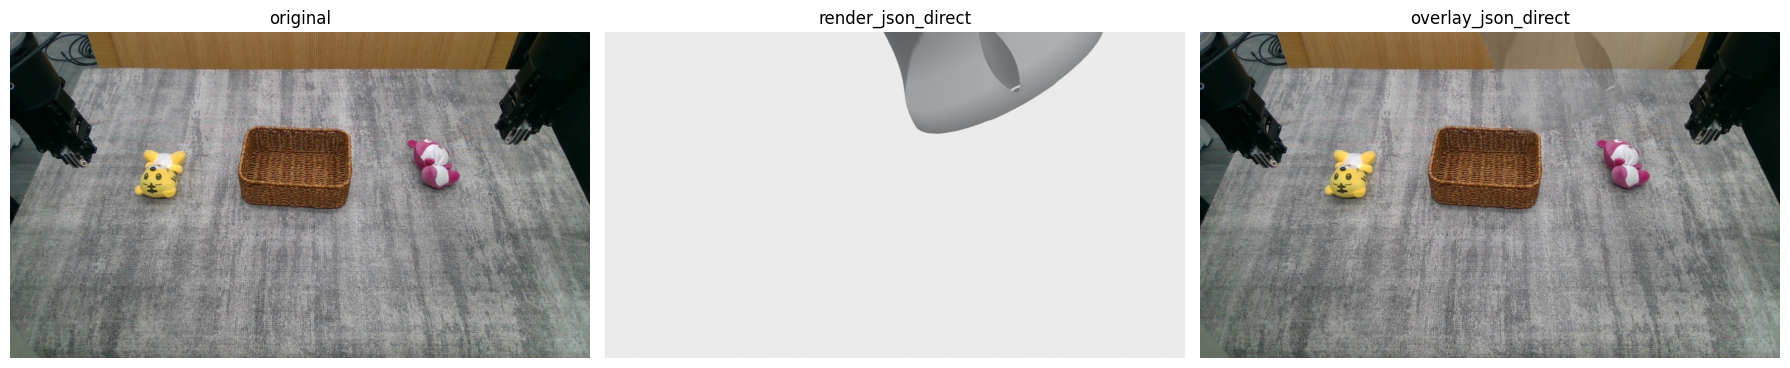

In [5]:
# Handcrafted JSON -> robot render logic (reuse real paths already used in this notebook)
import os
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.spatial.transform import Rotation as R

WORKSPACE_ROOT = '/home/haoxiang/rise2_mask_aware'
AIREXO_ROOT = os.path.join(WORKSPACE_ROOT, 'airexo')
for p in [WORKSPACE_ROOT, AIREXO_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

for _m in [m for m in list(sys.modules.keys()) if m == 'airexo' or m.startswith('airexo.')]:
    del sys.modules[_m]

from airexo.helpers.renderer import SeparateRobotRenderer
from omegaconf import OmegaConf

# =========================
# 直接复用 notebook 前面已经存在的真实路径变量
# =========================
# 依赖前面 cell 已经定义好的：
# - LEFT_JSON
# - RIGHT_JSON
# - rgb_path
# - intrinsic
# - WORKSPACE_ROOT

LEFT_CFG_PATH = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/configs/joint/left/robot.yaml')
RIGHT_CFG_PATH = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/configs/joint/right/robot.yaml')
LEFT_URDF = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/urdf_models/robot/left_robot.urdf')
RIGHT_URDF = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/urdf_models/robot/right_robot.urdf')

# 这里先严格按 JSON 语义：把 pose_in_link 直接当成 camera -> left/right base
USE_JSON_DIRECTLY_AS_CAM_TO_BASE = True

# 先给一个可跑的 joint 输入。
# 如果你后面想换成某一帧的真实 joint，再直接改这里。
LEFT_JOINT_RENDER = np.zeros(8, dtype=np.float32)
RIGHT_JOINT_RENDER = np.zeros(8, dtype=np.float32)
if 'lowdim' in globals():
    if 'gripper_left' in lowdim:
        LEFT_JOINT_RENDER[-1] = float(np.asarray(lowdim['gripper_left'])[0])
    if 'gripper_right' in lowdim:
        RIGHT_JOINT_RENDER[-1] = float(np.asarray(lowdim['gripper_right'])[0])


def pose7_wxyz_to_mat_local(pose7):
    pose7 = np.asarray(pose7, dtype=np.float64).reshape(7)
    t = pose7[:3]
    qw, qx, qy, qz = pose7[3:]
    T = np.eye(4, dtype=np.float64)
    T[:3, :3] = R.from_quat([qx, qy, qz, qw]).as_matrix()
    T[:3, 3] = t
    return T


def load_pose_in_link_local(json_path):
    data = json.loads(Path(json_path).read_text())
    return pose7_wxyz_to_mat_local(np.asarray(data['pose_in_link'], dtype=np.float64))


left_cfg = OmegaConf.load(LEFT_CFG_PATH)
right_cfg = OmegaConf.load(RIGHT_CFG_PATH)
image = np.array(Image.open(rgb_path))
height, width = image.shape[:2]

json_cam_to_left_base = load_pose_in_link_local(LEFT_JSON)
json_cam_to_right_base = load_pose_in_link_local(RIGHT_JSON)

if USE_JSON_DIRECTLY_AS_CAM_TO_BASE:
    cam_to_left_base_used = json_cam_to_left_base.copy()
    cam_to_right_base_used = json_cam_to_right_base.copy()
else:
    cam_to_left_base_used = json_cam_to_left_base.copy()
    cam_to_right_base_used = json_cam_to_right_base.copy()

renderer_sep = SeparateRobotRenderer(
    left_joint_cfgs=left_cfg,
    right_joint_cfgs=right_cfg,
    cam_to_left_base=cam_to_left_base_used,
    cam_to_right_base=cam_to_right_base_used,
    intrinsic=intrinsic,
    width=width,
    height=height,
    urdf_file={
        'left': LEFT_URDF,
        'right': RIGHT_URDF,
    },
)
renderer_sep.update_joints(LEFT_JOINT_RENDER, RIGHT_JOINT_RENDER)
render_sep = renderer_sep.render_image()
mask_sep = renderer_sep.render_mask()

alpha = 0.55
overlay_sep = image.copy()
overlay_sep[mask_sep > 0] = (
    alpha * image[mask_sep > 0] + (1 - alpha) * render_sep[mask_sep > 0]
).astype(np.uint8)

print('LEFT_JSON =', LEFT_JSON)
print('RIGHT_JSON =', RIGHT_JSON)
print('rgb_path =', rgb_path)
print('LEFT_JOINT_RENDER =', LEFT_JOINT_RENDER)
print('RIGHT_JOINT_RENDER =', RIGHT_JOINT_RENDER)
print('json_cam_to_left_base =\n', json_cam_to_left_base)
print('json_cam_to_right_base =\n', json_cam_to_right_base)
print('cam_to_left_base_used =\n', cam_to_left_base_used)
print('cam_to_right_base_used =\n', cam_to_right_base_used)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.title('original')
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('render_json_direct')
plt.imshow(render_sep)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('overlay_json_direct')
plt.imshow(overlay_sep)
plt.axis('off')
plt.tight_layout()
plt.show()


In [6]:
# Renderer branch A: strict shared cam_to_base branch (mimic CalibrationInfo.get_camera_to_base + RobotRenderer)
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

WORKSPACE_ROOT = '/home/haoxiang/rise2_mask_aware'
AIREXO_ROOT = os.path.join(WORKSPACE_ROOT, 'airexo')
for p in [WORKSPACE_ROOT, AIREXO_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

for _m in [m for m in list(sys.modules.keys()) if m == 'airexo' or m.startswith('airexo.')]:
    del sys.modules[_m]

from airexo.helpers.constants import (
    ROBOT_PREDEFINED_TRANSFORMATION,
    ROBOT_LEFT_REAL_BASE_TO_REAL_BASE,
    ROBOT_RIGHT_REAL_BASE_TO_REAL_BASE,
)
from airexo.helpers.rotation import average_xyz_rot_quat
from mask.renderer import ArmOnlyRobotRenderer

LEFT_CFG_PATH = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/configs/joint/left/robot.yaml')
RIGHT_CFG_PATH = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/configs/joint/right/robot.yaml')
URDF_PATH = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/urdf_models/robot/robot_inhand.urdf')

left_cfg = OmegaConf.load(LEFT_CFG_PATH)
right_cfg = OmegaConf.load(RIGHT_CFG_PATH)

rgb_bgr_local = cv2.imread(str(rgb_path), cv2.IMREAD_COLOR)
assert rgb_bgr_local is not None, rgb_path
rgb_local = cv2.cvtColor(rgb_bgr_local, cv2.COLOR_BGR2RGB)
height_local, width_local = rgb_local.shape[:2]

cam_to_overall_real_base_from_left = cam_to_left_base @ ROBOT_LEFT_REAL_BASE_TO_REAL_BASE
cam_to_overall_real_base_from_right = cam_to_right_base @ ROBOT_RIGHT_REAL_BASE_TO_REAL_BASE
cam_to_overall_real_base_avg = average_xyz_rot_quat(
    cam_to_overall_real_base_from_left,
    cam_to_overall_real_base_from_right,
    rotation_rep='matrix'
)
cam_to_base_shared = cam_to_overall_real_base_avg @ np.linalg.inv(ROBOT_PREDEFINED_TRANSFORMATION)

renderer_shared = ArmOnlyRobotRenderer(
    left_joint_cfgs=left_cfg,
    right_joint_cfgs=right_cfg,
    cam_to_base=cam_to_base_shared,
    intrinsic=intrinsic,
    urdf_file=URDF_PATH,
    width=width_local,
    height=height_local,
    near_plane=0.01,
    far_plane=100.0,
)
renderer_shared.update_joints(left_joint, right_joint)
render_shared = renderer_shared.render_image()
mask_shared = renderer_shared.render_mask()

overlay_shared = rgb_local.copy()
overlay_shared[mask_shared > 0] = (
    0.6 * render_shared[mask_shared > 0] + 0.4 * overlay_shared[mask_shared > 0]
).astype(np.uint8)

print('cam_to_overall_real_base_from_left =\n', cam_to_overall_real_base_from_left)
print('cam_to_overall_real_base_from_right =\n', cam_to_overall_real_base_from_right)
print('cam_to_base_shared =\n', cam_to_base_shared)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.title('shared branch | real rgb')
plt.imshow(rgb_local)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('shared branch | render')
plt.imshow(render_shared)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('shared branch | overlay')
plt.imshow(overlay_shared)
plt.axis('off')
plt.tight_layout()
plt.show()


NameError: name 'left_joint' is not defined

In [ ]:
# Renderer branch B: strict separate cam_to_left_base / cam_to_right_base branch (mimic SeparateRobotRenderer)
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

WORKSPACE_ROOT = '/home/haoxiang/rise2_mask_aware'
AIREXO_ROOT = os.path.join(WORKSPACE_ROOT, 'airexo')
for p in [WORKSPACE_ROOT, AIREXO_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

for _m in [m for m in list(sys.modules.keys()) if m == 'airexo' or m.startswith('airexo.')]:
    del sys.modules[_m]

from airexo.helpers.renderer import SeparateRobotRenderer

LEFT_CFG_PATH = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/configs/joint/left/robot.yaml')
RIGHT_CFG_PATH = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/configs/joint/right/robot.yaml')
LEFT_URDF = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/urdf_models/robot/left_robot.urdf')
RIGHT_URDF = os.path.join(WORKSPACE_ROOT, 'airexo/airexo/urdf_models/robot/right_robot.urdf')

left_cfg = OmegaConf.load(LEFT_CFG_PATH)
right_cfg = OmegaConf.load(RIGHT_CFG_PATH)

rgb_bgr_local = cv2.imread(str(rgb_path), cv2.IMREAD_COLOR)
assert rgb_bgr_local is not None, rgb_path
rgb_local = cv2.cvtColor(rgb_bgr_local, cv2.COLOR_BGR2RGB)
height_local, width_local = rgb_local.shape[:2]

renderer_sep = SeparateRobotRenderer(
    left_joint_cfgs=left_cfg,
    right_joint_cfgs=right_cfg,
    cam_to_left_base=cam_to_left_base,
    cam_to_right_base=cam_to_right_base,
    intrinsic=intrinsic,
    width=width_local,
    height=height_local,
    urdf_file={
        'left': LEFT_URDF,
        'right': RIGHT_URDF,
    },
)
renderer_sep.update_joints(left_joint, right_joint)
render_sep = renderer_sep.render_image()
mask_sep = renderer_sep.render_mask()

overlay_sep = rgb_local.copy()
overlay_sep[mask_sep > 0] = (
    0.6 * render_sep[mask_sep > 0] + 0.4 * overlay_sep[mask_sep > 0]
).astype(np.uint8)

print('cam_to_left_base =\n', cam_to_left_base)
print('cam_to_right_base =\n', cam_to_right_base)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.title('separate branch | real rgb')
plt.imshow(rgb_local)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('separate branch | render')
plt.imshow(render_sep)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('separate branch | overlay')
plt.imshow(overlay_sep)
plt.axis('off')
plt.tight_layout()
plt.show()
